# Getting started with maps and light curves
This getting-started example generates one Q2237+0305 image-B-like microlensing realization with the high-accuracy production IPM configuration. It uses $N=10^7$, $k=2$, true $r=2$, virtual $v=4$, dual-scout normalization, a $16\times16$ local-membership partition with an $8\times8$ complex-Taylor far-field lattice per cell, temporal batch 40, and a 10-frame endpoint-union scout refresh. It returns daily light curves with and without intrinsic variability from one shared 25-day dynamic-map sequence, identifies caustics and anchor/gauge center labels at all 147 map epochs, and writes an animated GIF of the moving magnification map and caustic network.

The calculation is intentionally substantial enough to demonstrate the real CUDA/Triton workflow. Install `microcaustics[notebooks,science]` and run on a CUDA GPU for the intended performance. The astrophysical realization is representative rather than a claim to reproduce one uniquely measured stellar field.

## Runtime and output controls
The default values below run the full 10-year, 147-map calculation. Set `GENERATE_GIF=False` to retain only the light curves and caustic labels. The output directory contains the GIF and compact NPZ light-curve/label product. The full $1024^2\times147$ map cube is never stored.

In [1]:
from pathlib import Path
import json
import math
import numpy as np
import torch
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt, label as connected_components
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
GENERATE_GIF = True
OUTPUT_DIRECTORY = Path('q2237_production_tutorial_output')
OUTPUT_DIRECTORY.mkdir(exist_ok=True)

capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device='cuda' if use_cuda else 'cpu',
    backend='triton' if use_cuda else 'auto',
    dtype=torch.float32,
    strict_backend=use_cuda,
    memory_fraction=0.85,
)
runtime = mc.resolve_runtime(runtime_config)
print(mcp.runtime_description())
print('Selected device/backend:', runtime.device, runtime.backend.value)
if not use_cuda:
    print('CUDA/Triton unavailable: this full configuration will be much slower.')


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
Selected device/backend: cuda triton


## Q2237 image-B-like macro lens and moving stellar field
The local convergence, shear amplitude, shear orientation, and redshifts define the macroimage. A truncated Salpeter population with mean mass $0.3\,M_\odot$ is drawn inside an explicit circular stellar aperture. Independent stellar velocities are combined with a coherent bulk drift, so the magnification pattern genuinely evolves.

In [2]:
lens_redshift, source_redshift = 0.0395, 1.695
distances = mc.LensingDistances.from_redshifts(lens_redshift, source_redshift)
macro = mc.MacroLens(
    convergence=0.391,
    shear=0.391,
    shear_angle_deg=141.73,
    smooth_matter_fraction=0.0,
)
population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.IsotropicKinematics(
        dispersion_km_s=60.0474,
        bulk_velocity_km_s=(-232.028, 300.612),
    ),
)
print('The source model below will set the source field; the complete circular stellar aperture is derived from it.')


The source model below will set the source field; the complete circular stellar aperture is derived from it.


## Full-Kerr multiband continuum source and intrinsic driver
A primary-image Kerr transfer supplies light bending and frequency shifts for the static Page--Thorne disk. The intrinsic component is a positive lognormal broken-power-law-PSD modulation sampled daily. This tutorial deliberately uses the spatially coherent multiplicative approximation, so the no-variability curve is recovered exactly by dividing out its known amplitude after the shared multirate calculation. Delayed thermal reprocessing is a separate physical option demonstrated in the transfer-function tutorials.


Map epochs: 147 daily flux epochs: 3651
Full-Kerr hit fraction: 0.7756767272949219


Stars: 3748 realized circular kappa_*: 0.3899
Derived source/lens fields [microarcsec]: (9.137793202108204, 9.137793202108204) (735.8205505101905, 735.8205505101905)


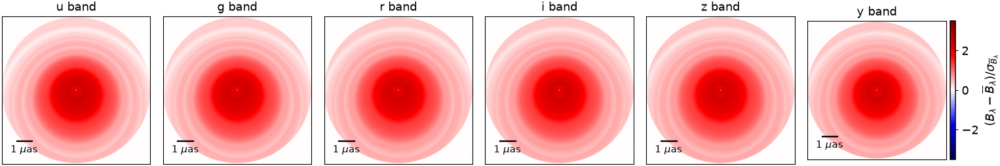

In [3]:
source_resolution = 1024
black_hole_mass_solar = 10.0**9.08
spin = 0.74
inclination_deg = 10.0
position_angle_deg = 175.0
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
driver = mc.broken_power_law_driving_signal(
    flux_times,
    break_timescale_days=200.0,
    low_frequency_slope=1.0,
    high_frequency_slope=3.0,
    standard_deviation=0.10,
    seed=12,
    extrapolation='hold',
)
disk_model = mc.KerrDiskModel(
    black_hole_mass_solar=black_hole_mass_solar,
    eddington_ratio=0.34,
    wavelengths_angstrom=(3671.0, 4827.0, 6223.0, 7546.0, 8691.0, 9712.0),
    band_names=('u', 'g', 'r', 'i', 'z', 'y'),
    spin=spin,
    inclination_deg=inclination_deg,
    position_angle_deg=position_angle_deg,
    source_redshift=source_redshift,
    lamp_fraction=0.1,
    corona_height_above_isco_rg=20.0,
    grid=mc.SourceGridConfig(
        shape=source_resolution, enclosed_flux_fraction=0.999, margin=1.05,
    ),
    compile_solver=use_cuda,
    lamppost_nalpha=1024 if use_cuda else 256,
    lamppost_radial_bins=512 if use_cuda else 128,
)
source_grid = disk_model.recommended_grid(distances)
static_disk = disk_model.pixelate(distances, grid=source_grid, runtime=runtime)
variable_disk = mc.ModulatedSource(static_disk, driver)
geometry = variable_disk.geometry
gravitational_radius_m = float(mc.gravitational_radius_m(black_hole_mass_solar))
disk_outer_rg = disk_model.support_radius_m(distances) / gravitational_radius_m
half_size_rg = disk_outer_rg
half_size_m = disk_outer_rg * gravitational_radius_m
source_fov_uas = source_grid.field_of_view_uas[0]
print('Map epochs:', len(map_times), 'daily flux epochs:', len(flux_times))
print('Full-Kerr hit fraction:', float(static_disk.transfer.hit.float().mean().detach().cpu()))

# Preview the same Q2237-like relativistic disk geometry used in the
# dedicated transfer-function tutorial before generating its light curve.
preview_half_rg = disk_outer_rg
preview_source = disk_model.with_driving_signal(driver).pixelate(
    distances, grid=source_grid, runtime=runtime,
)
preview_geometry = preview_source.geometry
preview_isco_rg = float(mc.kerr_isco_radius(spin))
preview_times = torch.linspace(0.0, 3650.0, 24, dtype=torch.float64, device=runtime.device)
preview_cube = torch.cat([
    preview_source.brightness(chunk, dtype=torch.float64, device=runtime.device).detach().cpu()
    for chunk in preview_times.split(4)
], dim=0).numpy()
preview_mean = np.mean(preview_cube, axis=0, dtype=np.float64)
preview_std = np.std(preview_cube, axis=0, dtype=np.float64)
preview_physical_support = (
    preview_source.transfer.hit
    & (preview_source.transfer.radius_rg >= preview_isco_rg)
    & (preview_source.transfer.radius_rg <= disk_outer_rg)
).detach().cpu().numpy()
preview_support = np.broadcast_to(preview_physical_support[:, :, None], preview_mean.shape)
preview_valid = preview_support & (preview_std > np.finfo(np.float64).tiny)
preview_standardized = np.divide(
    preview_cube - preview_mean, preview_std,
    out=np.zeros_like(preview_cube), where=preview_valid[None],
)
preview_scores = np.nanstd(
    np.where(preview_valid[None], preview_standardized, np.nan), axis=(1, 2, 3)
)
disk_preview = np.nan_to_num(
    preview_standardized[int(np.nanargmax(preview_scores))],
    nan=0.0, posinf=3.5, neginf=-3.5,
)
for preview_band in range(disk_preview.shape[-1]):
    support = preview_support[:, :, preview_band]
    valid = preview_valid[:, :, preview_band]
    repair = support & ~valid
    if np.any(repair) and np.any(valid):
        nearest = distance_transform_edt(~valid, return_distances=False, return_indices=True)
        disk_preview[:, :, preview_band][repair] = disk_preview[:, :, preview_band][tuple(nearest[:, repair])]
    zero_labels, _ = connected_components(preview_mean[:, :, preview_band] <= 0.0)
    exterior = np.unique(np.concatenate((zero_labels[0], zero_labels[-1], zero_labels[:, 0], zero_labels[:, -1])))
    central = zero_labels[zero_labels.shape[0] // 2, zero_labels.shape[1] // 2]
    isolated = (zero_labels > 0) & ~np.isin(zero_labels, exterior)
    if central > 0:
        isolated &= zero_labels != central
    if np.any(isolated) and np.any(valid):
        nearest = distance_transform_edt(~valid, return_distances=False, return_indices=True)
        disk_preview[:, :, preview_band][isolated] = disk_preview[:, :, preview_band][tuple(nearest[:, isolated])]
half_uas = float(distances.source_length_to_uas(
    preview_half_rg * gravitational_radius_m, dtype=torch.float64
))
disk_figure, disk_axes = plt.subplots(1, 6, figsize=(15.6, 2.7))
for disk_index, (disk_axis, disk_band) in enumerate(zip(disk_axes, geometry.band_names, strict=True)):
    disk_values = disk_preview[:, :, disk_index]
    disk_artist = disk_axis.imshow(
        disk_values, origin='lower',
        extent=(-half_uas, half_uas, -half_uas, half_uas),
        cmap='seismic', vmin=-3.5, vmax=3.5,
    )
    disk_axis.set_title(f'{disk_band} band')
    disk_axis.set_xlim(-half_uas, half_uas)
    disk_axis.set_ylim(-half_uas, half_uas)
    mcp.add_scale_bar(disk_axis, 1.0, label=r'1 $\mu$as', color='black')
    mcp.hide_image_axes(disk_axis)
mcp.panel_colorbar(disk_figure, disk_axes[-1], disk_artist, label=r'$(B_\lambda-\overline{B}_\lambda)/\sigma_{\overline{B}_\lambda}$')
disk_figure.tight_layout()
disk_figure.savefig(OUTPUT_DIRECTORY / 'q2237_relativistic_disk.png', dpi=220, bbox_inches='tight', facecolor='white')

# The high-level system derives the full circular stellar aperture, star
# count, Einstein radii, angular velocities, and lens-plane bounds once.
system = mc.MicrolensingSystem.from_redshifts(
    lens_redshift=lens_redshift,
    source_redshift=source_redshift,
    H0=70.0,
    Om0=0.3,
    macro=macro,
    source=variable_disk,
    stellar_population=population,
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    source_support_radius_uas=0.5 * source_fov_uas,
    seed=1001,
    runtime=runtime_config,
    caustic_grid_shape=8192,
)
realization = system.realize()
simulation = realization.simulation
stars = realization.stars
lens_region = realization.lens_region
lens_grid = realization.lens_grid
source_grid = realization.source_grid
aperture_radius_uas = realization.stellar_aperture.radius_uas
realized_circular_kappa = float(stars.einstein_radius_uas.square().sum() / aperture_radius_uas**2)
print('Stars:', len(stars), 'realized circular kappa_*:', f'{realized_circular_kappa:.4f}')
print('Derived source/lens fields [microarcsec]:', source_grid.field_of_view_uas, lens_region.field_of_view_uas)


## Production dynamic IPM and shared multirate light curve
Only the slow magnification field is generated every 25 days. The source and light curve are evaluated daily by interpolating the two map--source contractions that bracket each epoch. Interpolated maps are never materialized. Analytic detA, marching squares, mapped caustics, and nine-anchor/nine-gauge source-center labels share the same per-epoch local-exact/Taylor far-field states. All 147 map epochs are retained at display resolution for the GIF, while the full-resolution map cube is never stored.

In [4]:
method = mc.production_ipm_config(dynamic=True)
schedule = mc.production_dynamic_config()

caustic_config = mc.CausticConfig(
    far_field_approx=method.far_field_approx,
    temporal_batch_size=40,
    jacobian_chunk_size=1_048_576,
    anchor_count=9,
    gauge_count=9,
    float64_label_fallback=False,
)

gif_maps, gif_times, gif_caustics = [], [], []
gif_center_magnifications = []
gif_center_labels, gif_crossings, gif_center_distances = [], [], []
def retain_gif_frame(index, labeled_frame):
    if GENERATE_GIF:
        magnification_map = labeled_frame.magnification_map
        caustic_frame = labeled_frame.caustics
        reduced = F.avg_pool2d(
            magnification_map.values[None, None], kernel_size=4, stride=4
        )[0, 0]
        gif_maps.append(reduced.detach().cpu())
        gif_times.append(float(magnification_map.time_days))
        center_row = magnification_map.values.shape[0] // 2
        center_column = magnification_map.values.shape[1] // 2
        gif_center_magnifications.append(
            float(magnification_map.values[center_row, center_column].detach().cpu())
        )
        caustics = caustic_frame.caustics
        valid = caustics.invalid_segment_mask
        valid = (
            torch.ones(caustics.segment_count, device=caustics.caustic_segments_uas.device, dtype=torch.bool)
            if valid is None else ~valid
        )
        gif_caustics.append(
            caustics.caustic_segments_uas[valid].detach().cpu().numpy()
        )
        gif_center_labels.append(int(caustic_frame.labels.center_label))
        gif_crossings.append(bool(caustic_frame.labels.center_crossing))
        gif_center_distances.append(float(caustic_frame.labels.center_distance_uas))

labeled_result = system.multirate_light_curve_with_labels(
    map_times,
    flux_times,
    method=method,
    schedule=schedule,
    caustics=caustic_config,
    map_observer=retain_gif_frame,
)
variable_curve = labeled_result.light_curve
amplitudes = driver.amplitudes(
    flux_times,
    bands=len(geometry.band_names),
    dtype=variable_curve.flux.dtype,
    device=variable_curve.flux.device,
)
microlensing_only_curve = mc.LightCurve(
    variable_curve.times_days,
    variable_curve.flux / amplitudes,
    variable_curve.band_names,
    unlensed_flux=variable_curve.unlensed_flux / amplitudes,
    metadata={'intrinsic_variability': False, 'derived_from_shared_maps': True},
    timing=variable_curve.timing,
)
print('Actual rasterizer:', variable_curve.metadata['dynamic_map_metadata'].get('rasterizer'))
print('Single end-to-end labeled workflow + GIF capture [s]:', variable_curve.timing.delivered_seconds)
print('Timing components [s]:', dict(variable_curve.timing.component_seconds))
print('This is not warmed LC-only timing: it includes caustics, labels, and synchronous CPU GIF-frame capture.')
crossing_times = labeled_result.map_times_days[labeled_result.crossing_events]
print('Center-label crossings:', int(crossing_times.numel()))
print('Crossing times [days]:', [round(float(value), 1) for value in crossing_times])
print('Retained GIF frames:', len(gif_maps), 'of', len(map_times))


# This identity is exact for the coherent multiplicative source model.  It
# guards against accidentally applying the driver twice or interpolating it
# on the sparse map cadence instead of the daily source cadence.
torch.testing.assert_close(
    microlensing_only_curve.flux * amplitudes,
    variable_curve.flux,
    rtol=2.0e-6,
    atol=0.0,
)
driver_values = amplitudes[:, 0].detach().cpu()
print(
    'Intrinsic driver: positive lognormal broken PSD; min/mean/max =',
    *(f'{value:.4f}' for value in (driver_values.min(), driver_values.mean(), driver_values.max())),
)
print('Coherent-driver divide-out check: passed')


Actual rasterizer: triton_direct_cell_temporal_batch
Single end-to-end labeled workflow + GIF capture [s]: 10.293577500036918
Timing components [s]: {'dynamic_maps': 7.725549100025091, 'source_brightness': 0.06158500036690384, 'map_source_contractions': 2.478889000543859}
This is not warmed LC-only timing: it includes caustics, labels, and synchronous CPU GIF-frame capture.
Center-label crossings: 1
Crossing times [days]: [2350.0]
Retained GIF frames: 147 of 147
Intrinsic driver: positive lognormal broken PSD; min/mean/max = 0.7969 1.0000 1.2621
Coherent-driver divide-out check: passed


## The actual source scout and biquadratic IPM cell
This cell reproduces Figure 3 of the paper exactly from its compact Q2237 image-B diagnostics, using the same plotting implementation as the manuscript. The left panel is the $k=2$ source-directed scout. The right panel traces the true $r=2$ nodes and evaluates the biquadratic representation on the virtual $v=4$ lattice. The PNG is regenerated below rather than loaded as a pre-rendered figure.


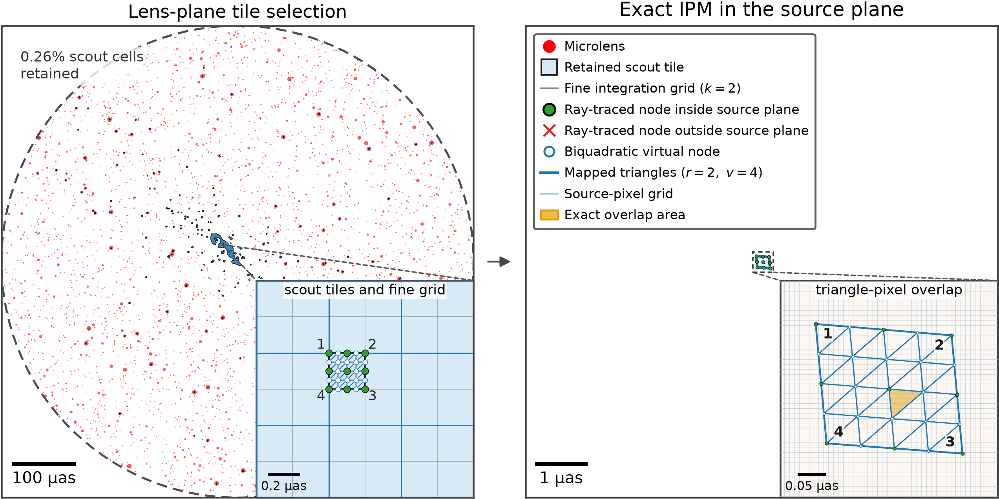

In [5]:
from IPython.display import Image, display

package_root = Path(mcp.__file__).resolve().parents[3]
method_fixtures = package_root / "examples" / "data" / "q2237b_method_figures"
paper_ipm_paths = mcp.render_paper_ipm_schematic(
    method_fixtures / "paper_tile_upsampling_schematic_data.npz",
    method_fixtures / "paper_far_field_schematic_data.npz",
    OUTPUT_DIRECTORY,
    refinement=2,
    virtual_refinement=4,
    source_bins=1024,
    output_prefix="q2237_image_b_scout_and_ipm",
)
display(Image(filename=str(paper_ipm_paths[0])))


## Light curves and labels at the source center
Both light curves contain the same finite-source microlensing realization. Their only difference is the known intrinsic driving signal. The second figure presents the source-center diagnostics separately from the GIF. They are center magnification, the caustic-crossing label, and the distance to the nearest caustic.

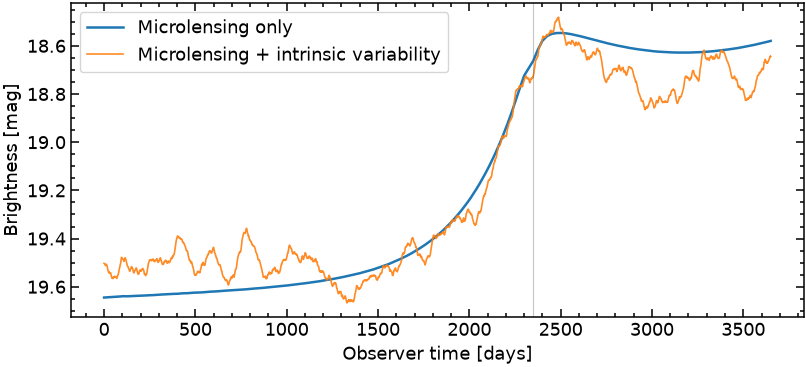

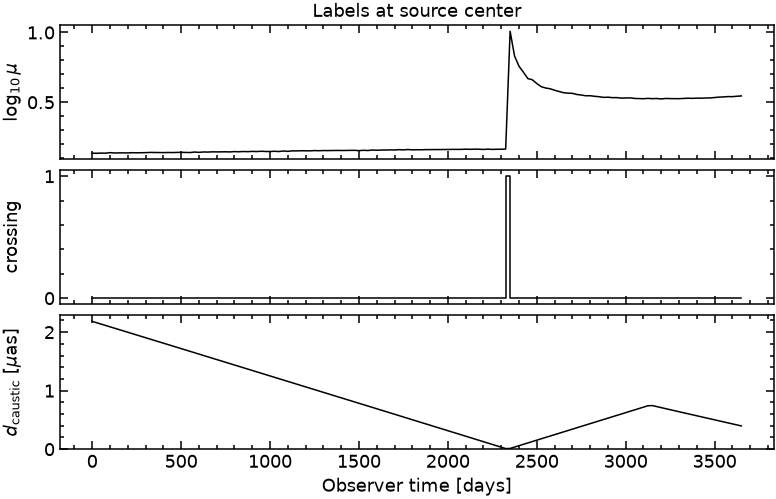

In [6]:
band = "i"
band_index = geometry.band_names.index(band)
# The physical source model returns internally consistent fluxes but does not
# assume an instrument zero point. Adopt one explicit mock calibration: the
# median unlensed i-band flux is 20 AB mag. All plotted differences then retain
# their physical flux ratios while the observable axis is in magnitudes.
reference_magnitude = 20.0
reference_flux = torch.median(variable_curve.unlensed_flux[:, band_index])

zero_point_flux = mc.zero_point_flux_for_magnitude(
    reference_flux, reference_magnitude
)

figure, ax = plt.subplots(figsize=(8.4, 4.0))
ax.plot(
    flux_times.numpy(),
    mc.flux_to_magnitude(microlensing_only_curve.flux[:, band_index], zero_point_flux).detach().cpu().numpy(),
    label="Microlensing only",
    linewidth=1.8,
)
ax.plot(
    flux_times.numpy(),
    mc.flux_to_magnitude(variable_curve.flux[:, band_index], zero_point_flux).detach().cpu().numpy(),
    label="Microlensing + intrinsic variability",
    linewidth=1.2,
    alpha=0.9,
)
for crossing_time in labeled_result.map_times_days[labeled_result.crossing_events]:
    ax.axvline(float(crossing_time), color="0.35", linewidth=0.8, alpha=0.35)
ax.set(xlabel="Observer time [days]", ylabel="Brightness [mag]")
ax.invert_yaxis()
ax.legend(frameon=True)
mcp.finish_axis(ax)
figure.tight_layout()

label_figure, label_axes = plt.subplots(
    3, 1, figsize=(8.4, 5.3), sharex=True, gridspec_kw={"hspace": 0.08}
)
label_axes[0].set_title("Labels at source center")
label_axes[0].plot(
    gif_times,
    np.log10(np.clip(gif_center_magnifications, 1.0e-12, None)),
    color="black",
    linewidth=1.1,
)
label_axes[0].set_ylabel(r"$\log_{10}\mu$")
label_axes[1].step(
    gif_times,
    np.asarray(gif_crossings, dtype=float),
    where="pre",
    color="black",
    linewidth=1.1,
)
label_axes[1].set(ylim=(-0.05, 1.05), yticks=(0, 1), ylabel="crossing")
label_axes[2].plot(gif_times, gif_center_distances, color="black", linewidth=1.1)
label_axes[2].set(
    ylim=(0.0, None),
    xlabel="Observer time [days]",
    ylabel=r"$d_{\rm caustic}$ [$\mu$as]",
)
for label_axis in label_axes:
    mcp.finish_axis(label_axis)
for label_axis in label_axes[:-1]:
    label_axis.tick_params(labelbottom=False)
label_figure.align_ylabels(label_axes)
label_figure.subplots_adjust(left=0.13, right=0.98, bottom=0.12, top=0.92)
label_figure.savefig(OUTPUT_DIRECTORY / "q2237_image_b_source_center_labels.png", dpi=180)

np.savez_compressed(
    OUTPUT_DIRECTORY / "q2237_image_b_light_curves.npz",
    times_days=flux_times.numpy(),
    flux_with_variability=variable_curve.flux.detach().cpu().numpy(),
    flux_without_variability=microlensing_only_curve.flux.detach().cpu().numpy(),
    unlensed_with_variability=variable_curve.unlensed_flux.detach().cpu().numpy(),
    band_names=np.asarray(variable_curve.band_names),
    map_times_days=labeled_result.map_times_days.numpy(),
    center_labels=labeled_result.crossing_labels.numpy(),
    center_crossings=labeled_result.crossing_events.numpy(),
    center_distance_uas=labeled_result.center_distances_uas.numpy(),
    metadata_json=np.asarray(json.dumps(dict(variable_curve.metadata), default=str)),
)


## Animate the moving magnification map
The GIF displays $\log_{10}\mu$ over the complete source-plane field with one normalization shared by all 147 frames. Blue curves are same-epoch mapped caustics in the same source-plane coordinate convention as the image. Labels remain in the separate diagnostic time series above. Downsampling is used only for the animation. Finite-source photometry used every $1024^2$ map pixel.

Wrote q2237_production_tutorial_output\q2237_image_b_moving_magnification_map.gif with one shared, dithered 256-color palette


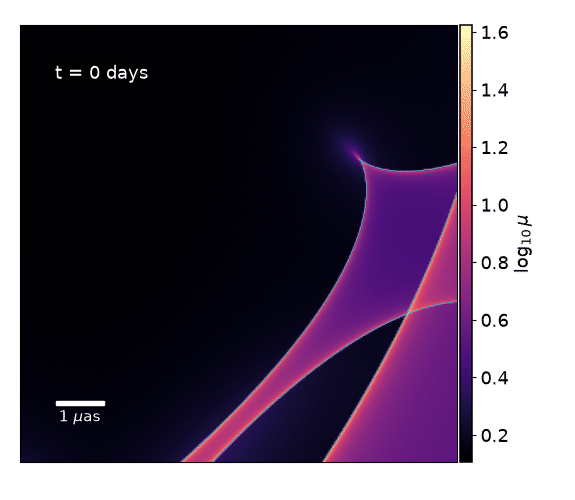

In [7]:
if GENERATE_GIF:
    log_maps = torch.log10(torch.stack(gif_maps).clamp_min(1.0e-2)).numpy()
    finite = log_maps[np.isfinite(log_maps)]
    vmin, vmax = float(finite.min()), float(finite.max())
    figure, ax = plt.subplots(figsize=(5.75, 5.0))
    xmin, xmax, ymin, ymax = source_grid.bounds_uas
    image = ax.imshow(
        log_maps[0],
        origin="lower",
        extent=(xmin, xmax, ymin, ymax),
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )
    time_text = ax.text(
        0.08, 0.91, "", transform=ax.transAxes, ha="left", va="top",
        color="white", fontsize=13, clip_on=False,
        bbox={"facecolor": "black", "edgecolor": "none", "alpha": 0.35, "pad": 2.5},
    )
    caustic_lines = LineCollection(
        gif_caustics[0], colors="deepskyblue", linewidths=0.55, alpha=0.9, zorder=8
    )
    ax.add_collection(caustic_lines, autolim=False)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    mcp.add_scale_bar(
        ax, 1.0, label=r"1 $\mu$as", location="lower left", color="white",
        font_size=11, thickness_fraction=0.007, borderpad=2.0, pad=0.35,
    )
    mcp.hide_image_axes(ax)
    ax.set_box_aspect(1)
    mcp.panel_colorbar(
        figure, ax, image, label=r"$\log_{{10}}\mu$", size="2.6%", pad=0.035
    )
    # Reserve explicit room for the colorbar label. This prevents the final
    # pixels from being clipped by notebook or GIF renderers.
    figure.subplots_adjust(left=0.035, right=0.82, bottom=0.045, top=0.98)

    rendered_frames = []
    for frame_index in range(len(gif_maps)):
        image.set_data(log_maps[frame_index])
        caustic_lines.set_segments(gif_caustics[frame_index])
        time_text.set_text(f"t = {gif_times[frame_index]:.0f} days")
        figure.canvas.draw()
        rendered_frames.append(np.asarray(figure.canvas.buffer_rgba())[..., :3].copy())

    gif_path = OUTPUT_DIRECTORY / "q2237_image_b_moving_magnification_map.gif"
    mcp.save_fixed_palette_gif(rendered_frames, gif_path, fps=8, dither=True)
    plt.close(figure)
    print("Wrote", gif_path, "with one shared, dithered 256-color palette")
    try:
        from IPython.display import Image, display
        display(Image(filename=str(gif_path)))
    except ImportError:
        pass


## Generate more realizations without compiling each one

Compiled kernels are cached by compatible numerical shape, not by the physical values in the lens or disk. The first compatible call in each process may compile. Later realizations can change convergence, shear, disk parameters, trajectory, velocities, variability, star positions, and random seed while reusing those kernels. For example, the following creates another stellar realization and evaluates it with the same numerical configuration. Constructing the new system performs physical setup but does not itself compile a kernel.

```python
from dataclasses import replace

second_system = replace(system, seed=1002)
second_result = second_system.multirate_light_curve_with_labels(
    map_times, flux_times, method=method, schedule=schedule, caustics=caustic_config
)
```

Keep the source-grid shape, band count, temporal batch size, dtype, backend, and IPM/far-field shape controls fixed for maximum reuse. Changing one of those shapes can create one new cached specialization. A substantially different stellar count can also create a new compiled-Torch shape variant.

The [fixed-system training-set tutorial](18_q2237_training_set.ipynb) executes this pattern for several independent Q2237 image-B realizations in one persistent worker. The [prior-sampled training-set tutorial](19_randomized_training_set.ipynb) changes both lens and disk parameters while retaining fixed numerical shapes. Their command-line examples keep one persistent process per GPU, so compilation is paid once per compatible worker rather than once per light curve.

The same pattern applies to any macroimage. Replace the local macro lens, stellar field, source, and output geometry while keeping the solver configuration explicit. For a fast exploratory run, lower the ray budget and source resolution deliberately. Do not silently relabel that result as the production configuration.